# Multi-dimentional data set:

In [26]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

In [6]:
x , y = make_regression(n_samples=500, n_features=10, noise=0.1)

In [7]:
print(x.shape, y.shape)

(500, 10) (500,)


In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size=0.35)

In [14]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(325, 10) (325,)
(175, 10) (175,)


In [15]:
def gausian_nd(x, center=0, eps=1):
    return np.exp(-eps*np.linalg.norm(x-center)**2)

In [31]:
m = 100
centers =[]
eps = 0.1

for j in range(m):
    centers.append(np.random.uniform(x_train.min(axis=0),
                  x_train.max(axis=0)))

In [32]:
phi = np.zeros((y_train.shape[0], m))

for i in range(phi.shape[0]):
    for j in range(phi.shape[1]):
        phi[i, j] = gausian_nd(x_train[i, :], center=centers[j], eps=eps)

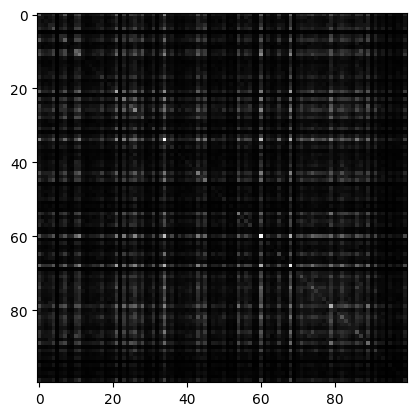

In [33]:
plt.imshow(phi.T@phi, cmap='gray');

In [35]:
l = np.linalg.inv(phi.T@phi)@phi.T@y_train

In [36]:
y_pred = []

for i in range(x_test.shape[0]):
    pred = 0
    for j in range(m):
        pred += l[j] * gausian_nd(x[i, :], center=centers[j], eps=eps)
    y_pred.append(pred)

y_pred = np.asarray(y_pred)